In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

matches = pd.read_csv('../dataset/matches.csv')
deliveries = pd.read_csv('../dataset/deliveries.csv')

print("Data loaded successfully!")

Data loaded successfully!


In [39]:
# Fix team name inconsistencies
team_name_map = {
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Delhi Capitals': 'Delhi Daredevils',
    'Punjab Kings': 'Kings XI Punjab',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}

matches.replace(team_name_map, inplace=True)
deliveries.replace(team_name_map, inplace=True)

print("Team names standardised!")

Team names standardised!


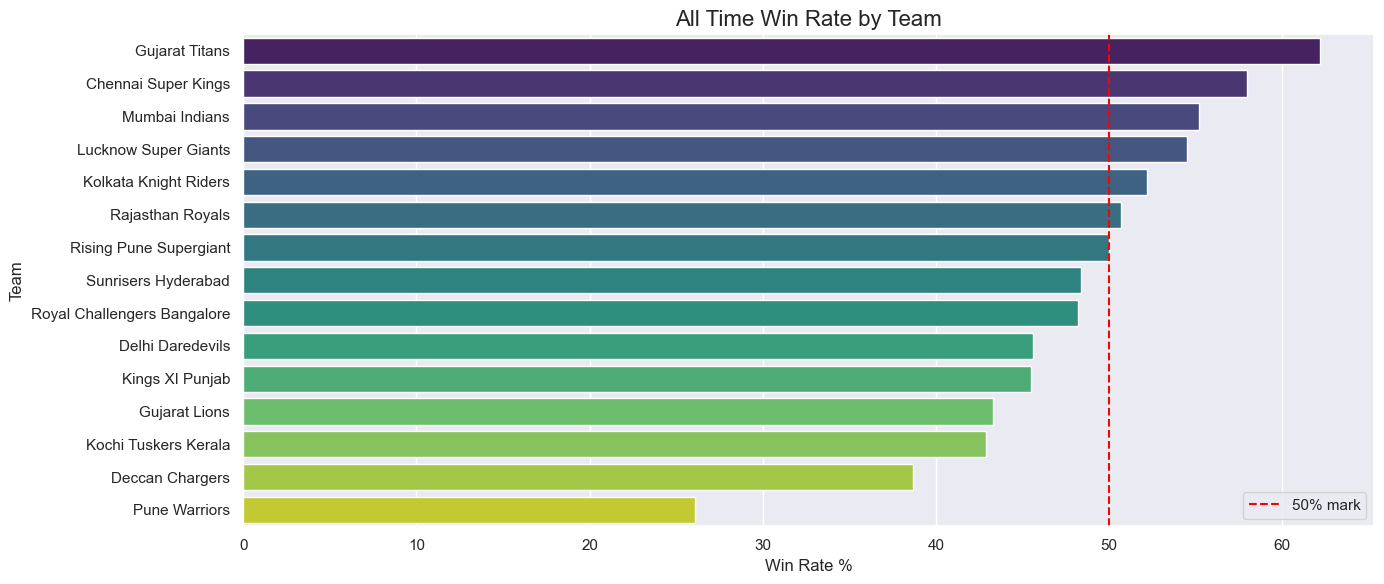

                       team  played  won  win_rate
             Gujarat Titans      45   28      62.2
        Chennai Super Kings     238  138      58.0
             Mumbai Indians     261  144      55.2
       Lucknow Super Giants      44   24      54.5
      Kolkata Knight Riders     251  131      52.2
           Rajasthan Royals     221  112      50.7
     Rising Pune Supergiant      30   15      50.0
        Sunrisers Hyderabad     182   88      48.4
Royal Challengers Bangalore     255  123      48.2
           Delhi Daredevils     252  115      45.6
            Kings XI Punjab     246  112      45.5
              Gujarat Lions      30   13      43.3
       Kochi Tuskers Kerala      14    6      42.9
            Deccan Chargers      75   29      38.7
              Pune Warriors      46   12      26.1


In [40]:
all_teams = pd.concat([matches['team1'], matches['team2']]).unique()

win_rates = []
for team in all_teams:
    played = matches[(matches['team1'] == team) | (matches['team2'] == team)]
    won = matches[matches['winner'] == team]
    win_rate = len(won) / len(played) * 100
    win_rates.append({'team': team, 'played': len(played), 'won': len(won), 'win_rate': round(win_rate, 1)})

win_rates_df = pd.DataFrame(win_rates).sort_values('win_rate', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=win_rates_df, x='win_rate', y='team', hue='team', palette='viridis', legend=False)
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% mark')
plt.title('All Time Win Rate by Team', fontsize=16)
plt.xlabel('Win Rate %')
plt.ylabel('Team')
plt.legend()
plt.tight_layout()
plt.show()

print(win_rates_df.to_string(index=False))

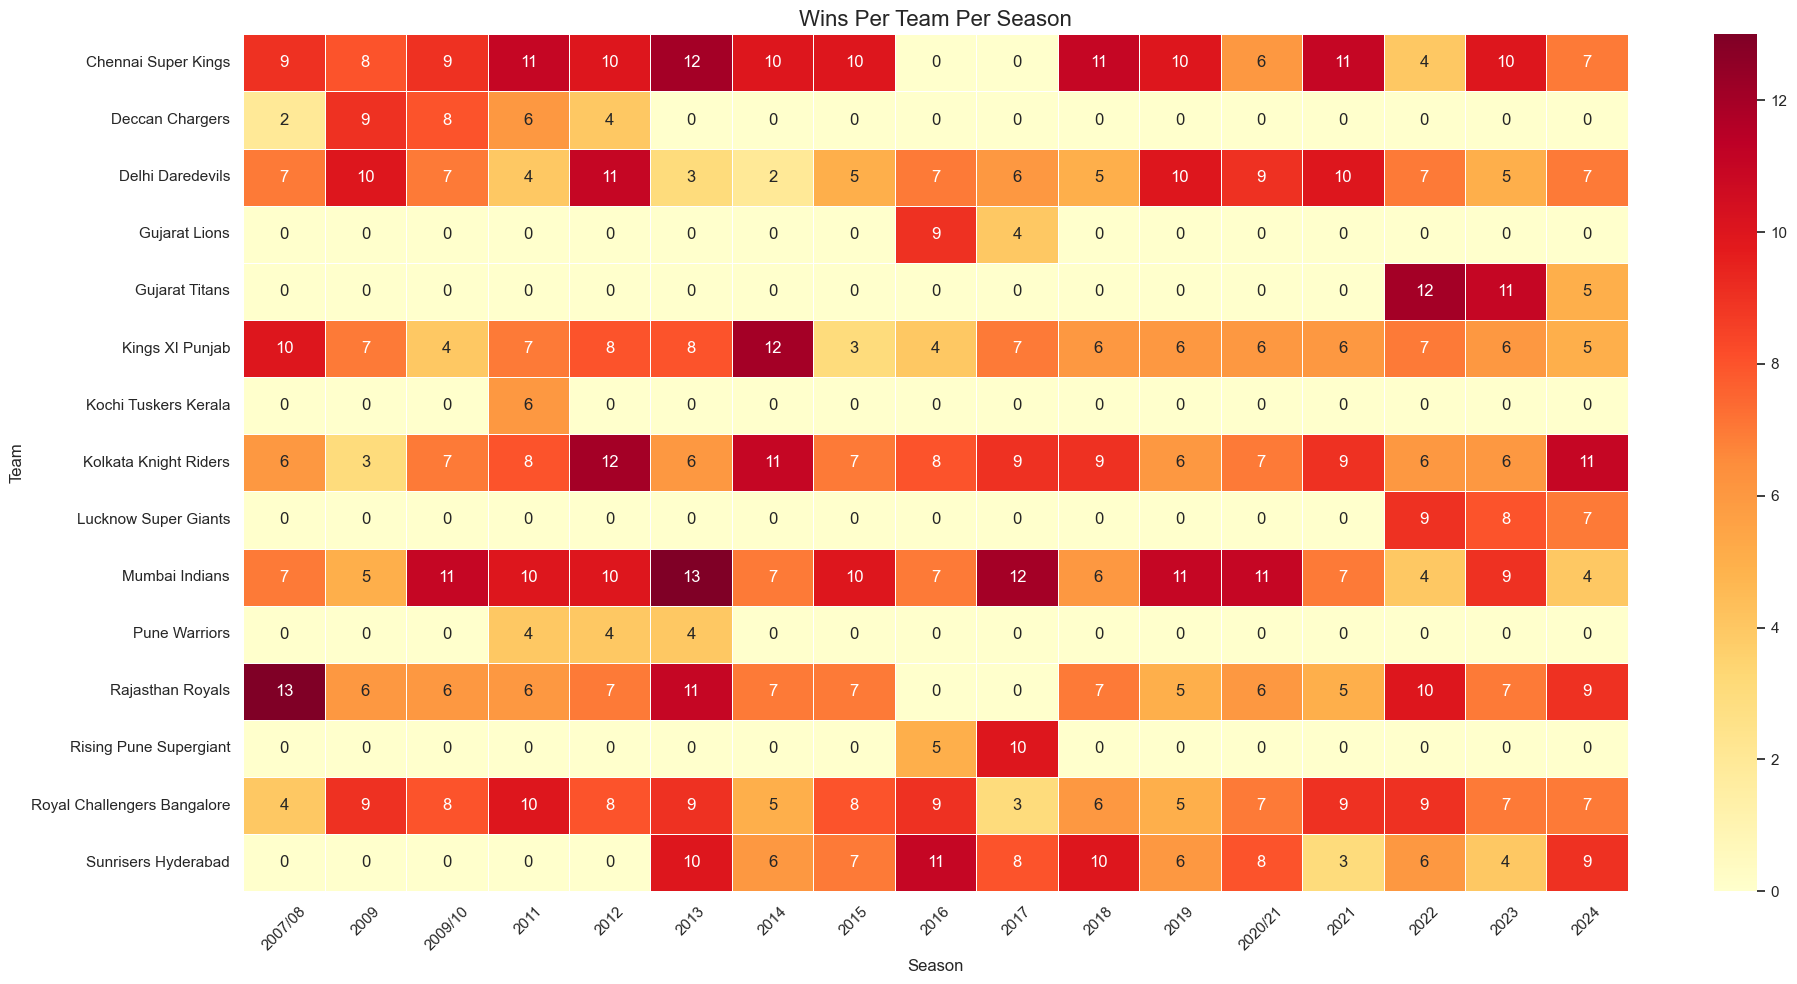

In [41]:
season_team_wins = matches.groupby(['season', 'winner']).size().reset_index(name='wins')
pivot = season_team_wins.pivot(index='winner', columns='season', values='wins').fillna(0)

plt.figure(figsize=(20, 10))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Wins Per Team Per Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Team')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

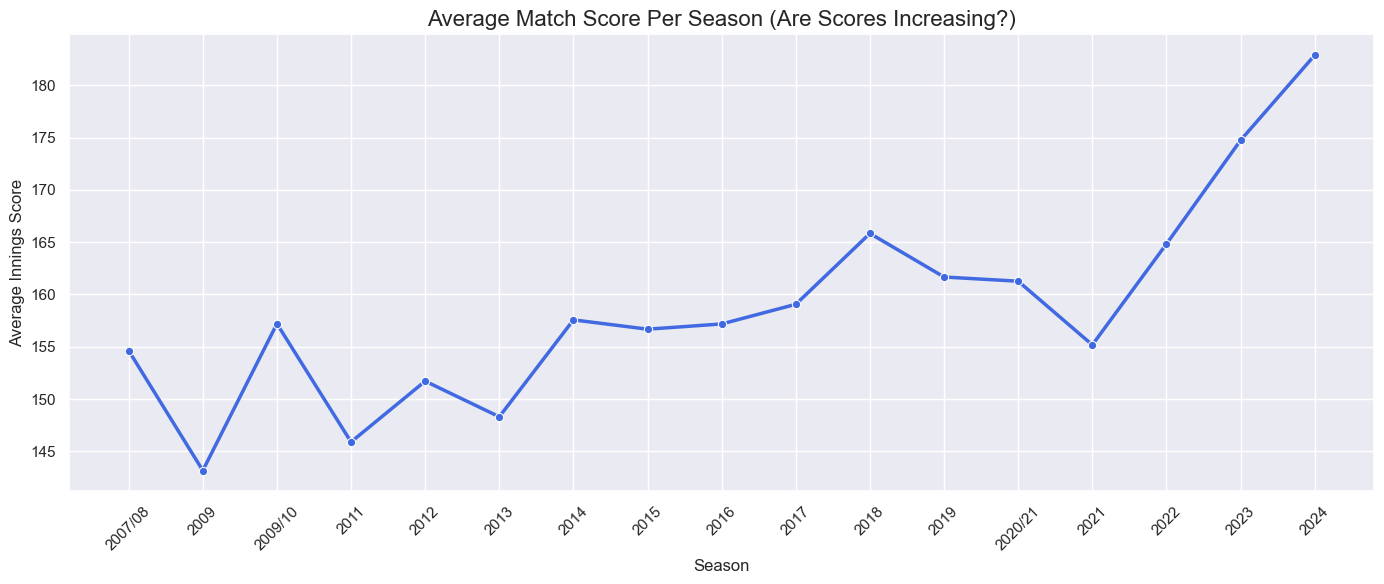

 season  avg_score
2007/08     154.63
   2009     143.16
2009/10     157.20
   2011     145.89
   2012     151.71
   2013     148.30
   2014     157.57
   2015     156.68
   2016     157.18
   2017     159.06
   2018     165.84
   2019     161.67
2020/21     161.27
   2021     155.18
   2022     164.83
   2023     174.75
   2024     182.89


In [42]:
match_scores = deliveries.groupby(['match_id', 'inning'])['total_runs'].sum().reset_index()
match_scores = match_scores[match_scores['inning'] <= 2]
match_scores = match_scores.merge(matches[['id', 'season']], left_on='match_id', right_on='id')

avg_scores = match_scores.groupby('season')['total_runs'].mean().reset_index()
avg_scores.columns = ['season', 'avg_score']
avg_scores['avg_score'] = avg_scores['avg_score'].round(2)

plt.figure(figsize=(14, 6))
sns.lineplot(data=avg_scores, x='season', y='avg_score', marker='o', linewidth=2.5, color='royalblue')
plt.title('Average Match Score Per Season (Are Scores Increasing?)', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Average Innings Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(avg_scores.to_string(index=False))

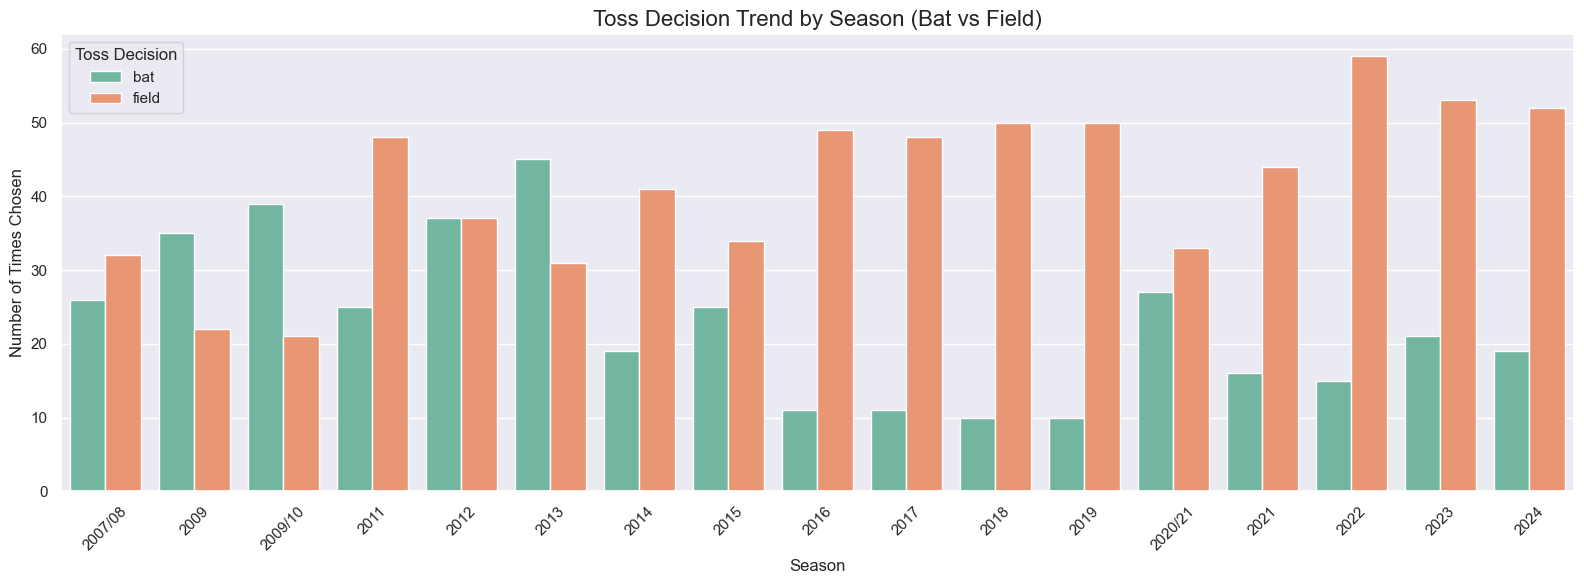

In [43]:
toss_by_season = matches.groupby(['season', 'toss_decision']).size().reset_index(name='count')

plt.figure(figsize=(16, 6))
sns.barplot(data=toss_by_season, x='season', y='count', hue='toss_decision', palette='Set2')
plt.title('Toss Decision Trend by Season (Bat vs Field)', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Number of Times Chosen')
plt.xticks(rotation=45)
plt.legend(title='Toss Decision')
plt.tight_layout()
plt.show()

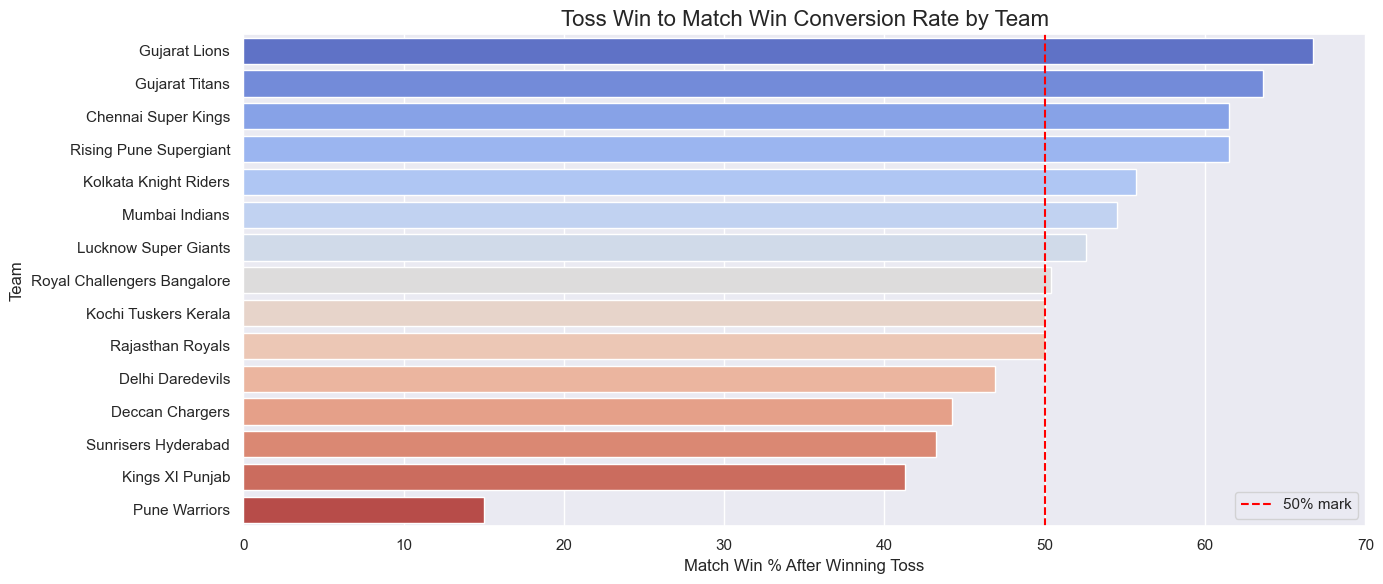

                       team  toss_and_match_wins  toss_wins  toss_win_conversion
              Gujarat Lions                   10         15                 66.7
             Gujarat Titans                   14         22                 63.6
        Chennai Super Kings                   75        122                 61.5
     Rising Pune Supergiant                    8         13                 61.5
      Kolkata Knight Riders                   68        122                 55.7
             Mumbai Indians                   78        143                 54.5
       Lucknow Super Giants                   10         19                 52.6
Royal Challengers Bangalore                   61        121                 50.4
       Kochi Tuskers Kerala                    4          8                 50.0
           Rajasthan Royals                   60        120                 50.0
           Delhi Daredevils                   61        130                 46.9
            Deccan Chargers 

In [44]:
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']

toss_effect = matches.groupby('toss_winner')['toss_won_match'].agg(['sum', 'count']).reset_index()
toss_effect.columns = ['team', 'toss_and_match_wins', 'toss_wins']
toss_effect['toss_win_conversion'] = (toss_effect['toss_and_match_wins'] / toss_effect['toss_wins'] * 100).round(1)
toss_effect = toss_effect.sort_values('toss_win_conversion', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=toss_effect, x='toss_win_conversion', y='team', hue='team', palette='coolwarm', legend=False)
plt.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% mark')
plt.title('Toss Win to Match Win Conversion Rate by Team', fontsize=16)
plt.xlabel('Match Win % After Winning Toss')
plt.ylabel('Team')
plt.legend()
plt.tight_layout()
plt.show()

print(toss_effect.to_string(index=False))

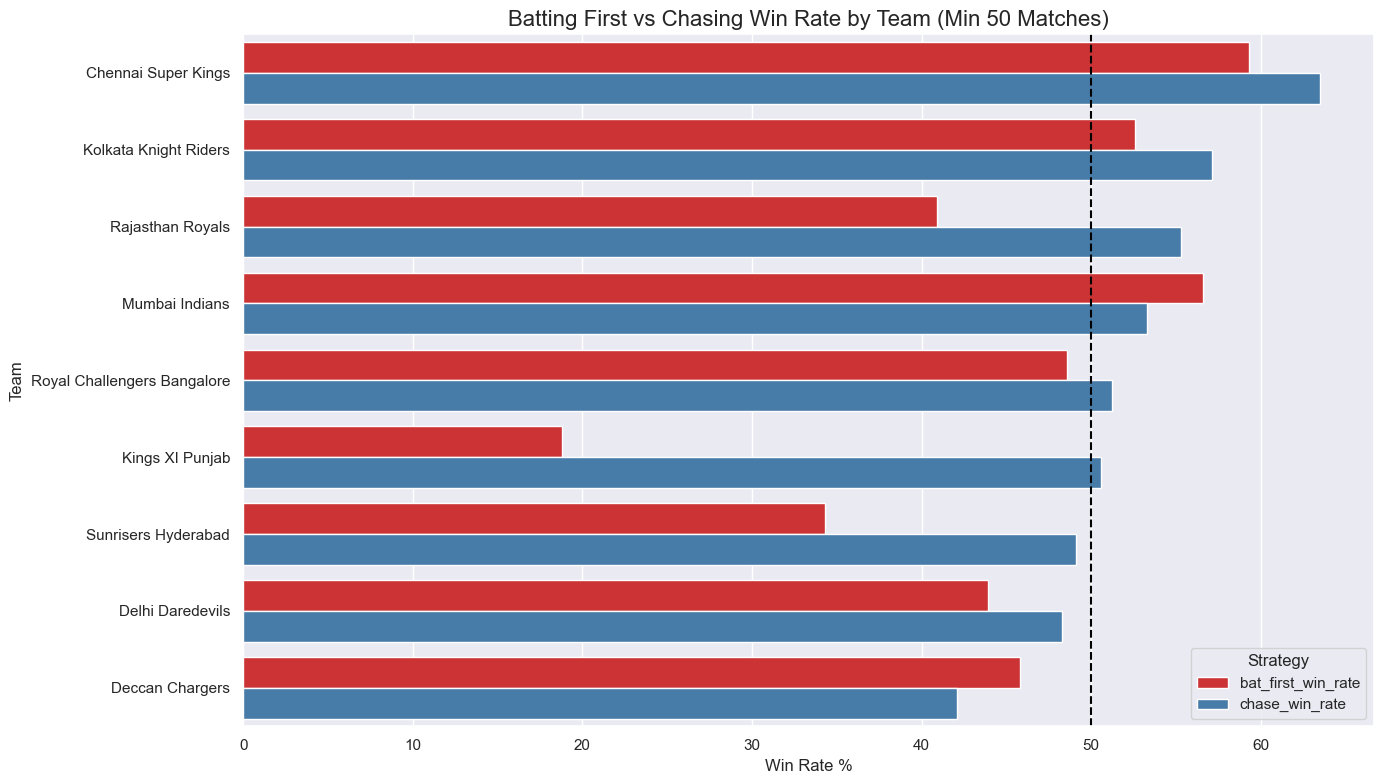

                       team  bat_first_win_rate  chase_win_rate
        Chennai Super Kings                59.3            63.5
      Kolkata Knight Riders                52.6            57.1
           Rajasthan Royals                40.9            55.3
             Mumbai Indians                56.6            53.3
Royal Challengers Bangalore                48.6            51.2
            Kings XI Punjab                18.8            50.6
        Sunrisers Hyderabad                34.3            49.1
           Delhi Daredevils                43.9            48.3
            Deccan Chargers                45.8            42.1


In [45]:
bat_first = matches[matches['toss_decision'] == 'bat'].copy()
bat_first['bat_first_team'] = bat_first['toss_winner']
bat_first['won_batting_first'] = bat_first['toss_winner'] == bat_first['winner']

chase = matches[matches['toss_decision'] == 'field'].copy()
chase['chasing_team'] = chase['toss_winner']
chase['won_chasing'] = chase['toss_winner'] == chase['winner']

bat_first_rates = bat_first.groupby('bat_first_team')['won_batting_first'].mean().reset_index()
bat_first_rates.columns = ['team', 'bat_first_win_rate']

chase_rates = chase.groupby('chasing_team')['won_chasing'].mean().reset_index()
chase_rates.columns = ['team', 'chase_win_rate']

combined = bat_first_rates.merge(chase_rates, on='team')
combined['bat_first_win_rate'] = (combined['bat_first_win_rate'] * 100).round(1)
combined['chase_win_rate'] = (combined['chase_win_rate'] * 100).round(1)

# Filter out teams with less than 50 matches played
valid_teams = win_rates_df[win_rates_df['played'] >= 50]['team'].tolist()
combined = combined[combined['team'].isin(valid_teams)]

combined = combined.sort_values('chase_win_rate', ascending=False)

combined_melted = combined.melt(id_vars='team', value_vars=['bat_first_win_rate', 'chase_win_rate'],
                                 var_name='strategy', value_name='win_rate')

plt.figure(figsize=(14, 8))
sns.barplot(data=combined_melted, x='win_rate', y='team', hue='strategy', palette='Set1')
plt.axvline(x=50, color='black', linestyle='--', linewidth=1.5)
plt.title('Batting First vs Chasing Win Rate by Team (Min 50 Matches)', fontsize=16)
plt.xlabel('Win Rate %')
plt.ylabel('Team')
plt.legend(title='Strategy')
plt.tight_layout()
plt.show()

print(combined.to_string(index=False))

In [51]:
# Only currently active IPL teams
active_teams = [
    'Chennai Super Kings',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Sunrisers Hyderabad',
    'Rajasthan Royals',
    'Delhi Daredevils',
    'Kings XI Punjab',
    'Lucknow Super Giants',
    'Gujarat Titans'
]

h2h_results = []
for team_a in active_teams:
    for team_b in active_teams:
        if team_a == team_b:
            continue
        h2h = matches[
            ((matches['team1'] == team_a) & (matches['team2'] == team_b)) |
            ((matches['team1'] == team_b) & (matches['team2'] == team_a))
        ]
        total = len(h2h)
        if total < 5:
            continue
        team_a_wins = len(h2h[h2h['winner'] == team_a])
        team_b_wins = len(h2h[h2h['winner'] == team_b])
        team_a_prob = round(team_a_wins / total * 100, 1)
        team_b_prob = round(team_b_wins / total * 100, 1)
        predicted_winner = team_a if team_a_prob > team_b_prob else team_b

        h2h_results.append({
            'Team A': team_a,
            'Team B': team_b,
            'Matches Played': total,
            'Team A Wins': team_a_wins,
            'Team B Wins': team_b_wins,
            'Team A Win %': team_a_prob,
            'Team B Win %': team_b_prob,
            'Predicted Winner': predicted_winner
        })

h2h_df = pd.DataFrame(h2h_results)

print("=== HEAD TO HEAD WIN PROBABILITIES ===\n")
print(h2h_df.to_string(index=False))

=== HEAD TO HEAD WIN PROBABILITIES ===

                     Team A                      Team B  Matches Played  Team A Wins  Team B Wins  Team A Win %  Team B Win %            Predicted Winner
        Chennai Super Kings              Mumbai Indians              37           17           20          45.9          54.1              Mumbai Indians
        Chennai Super Kings Royal Challengers Bangalore              32           21           11          65.6          34.4         Chennai Super Kings
        Chennai Super Kings       Kolkata Knight Riders              29           19           10          65.5          34.5         Chennai Super Kings
        Chennai Super Kings         Sunrisers Hyderabad              21           15            6          71.4          28.6         Chennai Super Kings
        Chennai Super Kings            Rajasthan Royals              29           16           13          55.2          44.8         Chennai Super Kings
        Chennai Super Kings         

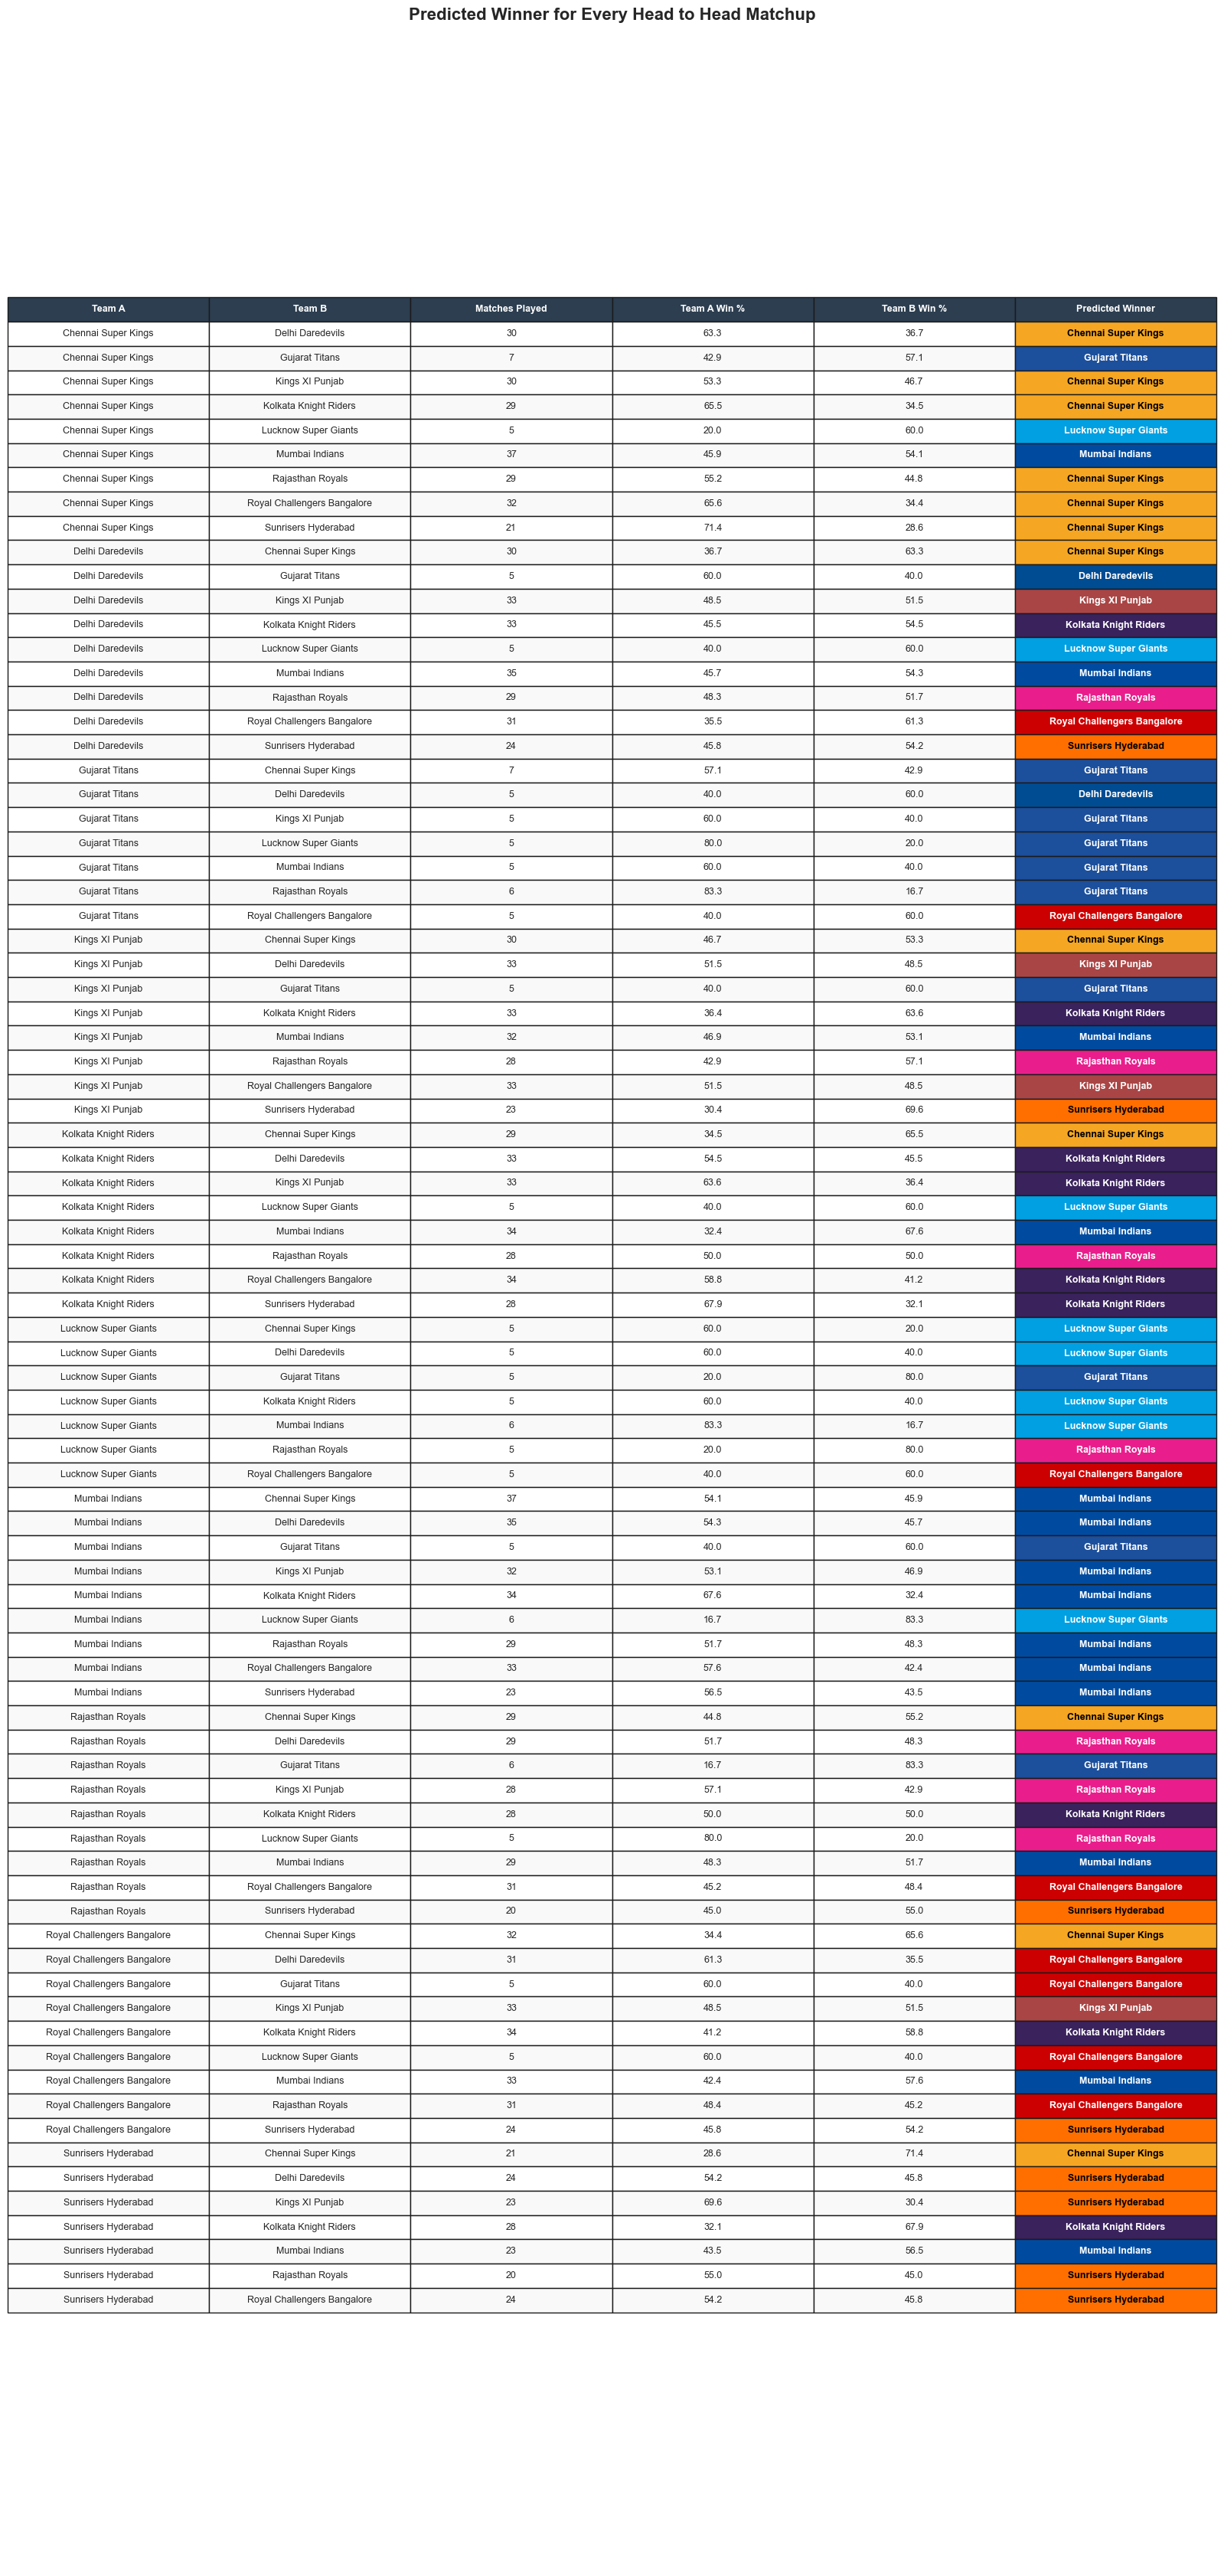

In [ ]:
# --- IPL TEAM COLOURS ---
team_colours = {
    'Chennai Super Kings':         '#f5a623',
    'Mumbai Indians':              '#004ba0',
    'Royal Challengers Bangalore': '#cc0001',
    'Kolkata Knight Riders':       '#3a225d',
    'Sunrisers Hyderabad':         '#ff6f00',
    'Rajasthan Royals':            '#e91e8c',
    'Delhi Daredevils':            '#004c93',
    'Kings XI Punjab':             '#aa4545',
    'Lucknow Super Giants':        '#00a0e2',
    'Gujarat Titans':              '#1c4f9c'
}

text_colours = {
    'Chennai Super Kings':         '#000000',
    'Mumbai Indians':              '#ffffff',
    'Royal Challengers Bangalore': '#ffffff',
    'Kolkata Knight Riders':       '#ffffff',
    'Sunrisers Hyderabad':         '#000000',
    'Rajasthan Royals':            '#ffffff',
    'Delhi Daredevils':            '#ffffff',
    'Kings XI Punjab':             '#ffffff',
    'Lucknow Super Giants':        '#ffffff',
    'Gujarat Titans':              '#ffffff'
}

# --- PREDICTED WINNER TABLE ---
winner_df = h2h_df[['Team A', 'Team B', 'Matches Played', 'Team A Win %', 'Team B Win %', 'Predicted Winner']].copy()
winner_df = winner_df.sort_values(['Team A', 'Team B']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, len(winner_df) * 0.4 + 1))
ax.axis('off')

table = ax.table(
    cellText=winner_df.values,
    colLabels=winner_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 5 and row > 0:
        team = winner_df.iloc[row - 1]['Predicted Winner']
        bg = team_colours.get(team, '#27ae60')
        fg = text_colours.get(team, '#ffffff')
        cell.set_facecolor(bg)
        cell.set_text_props(color=fg, fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f9f9f9')
    else:
        cell.set_facecolor('#ffffff')

plt.title('Predicted Winner for Every Head to Head Matchup (ALL TIME)', fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

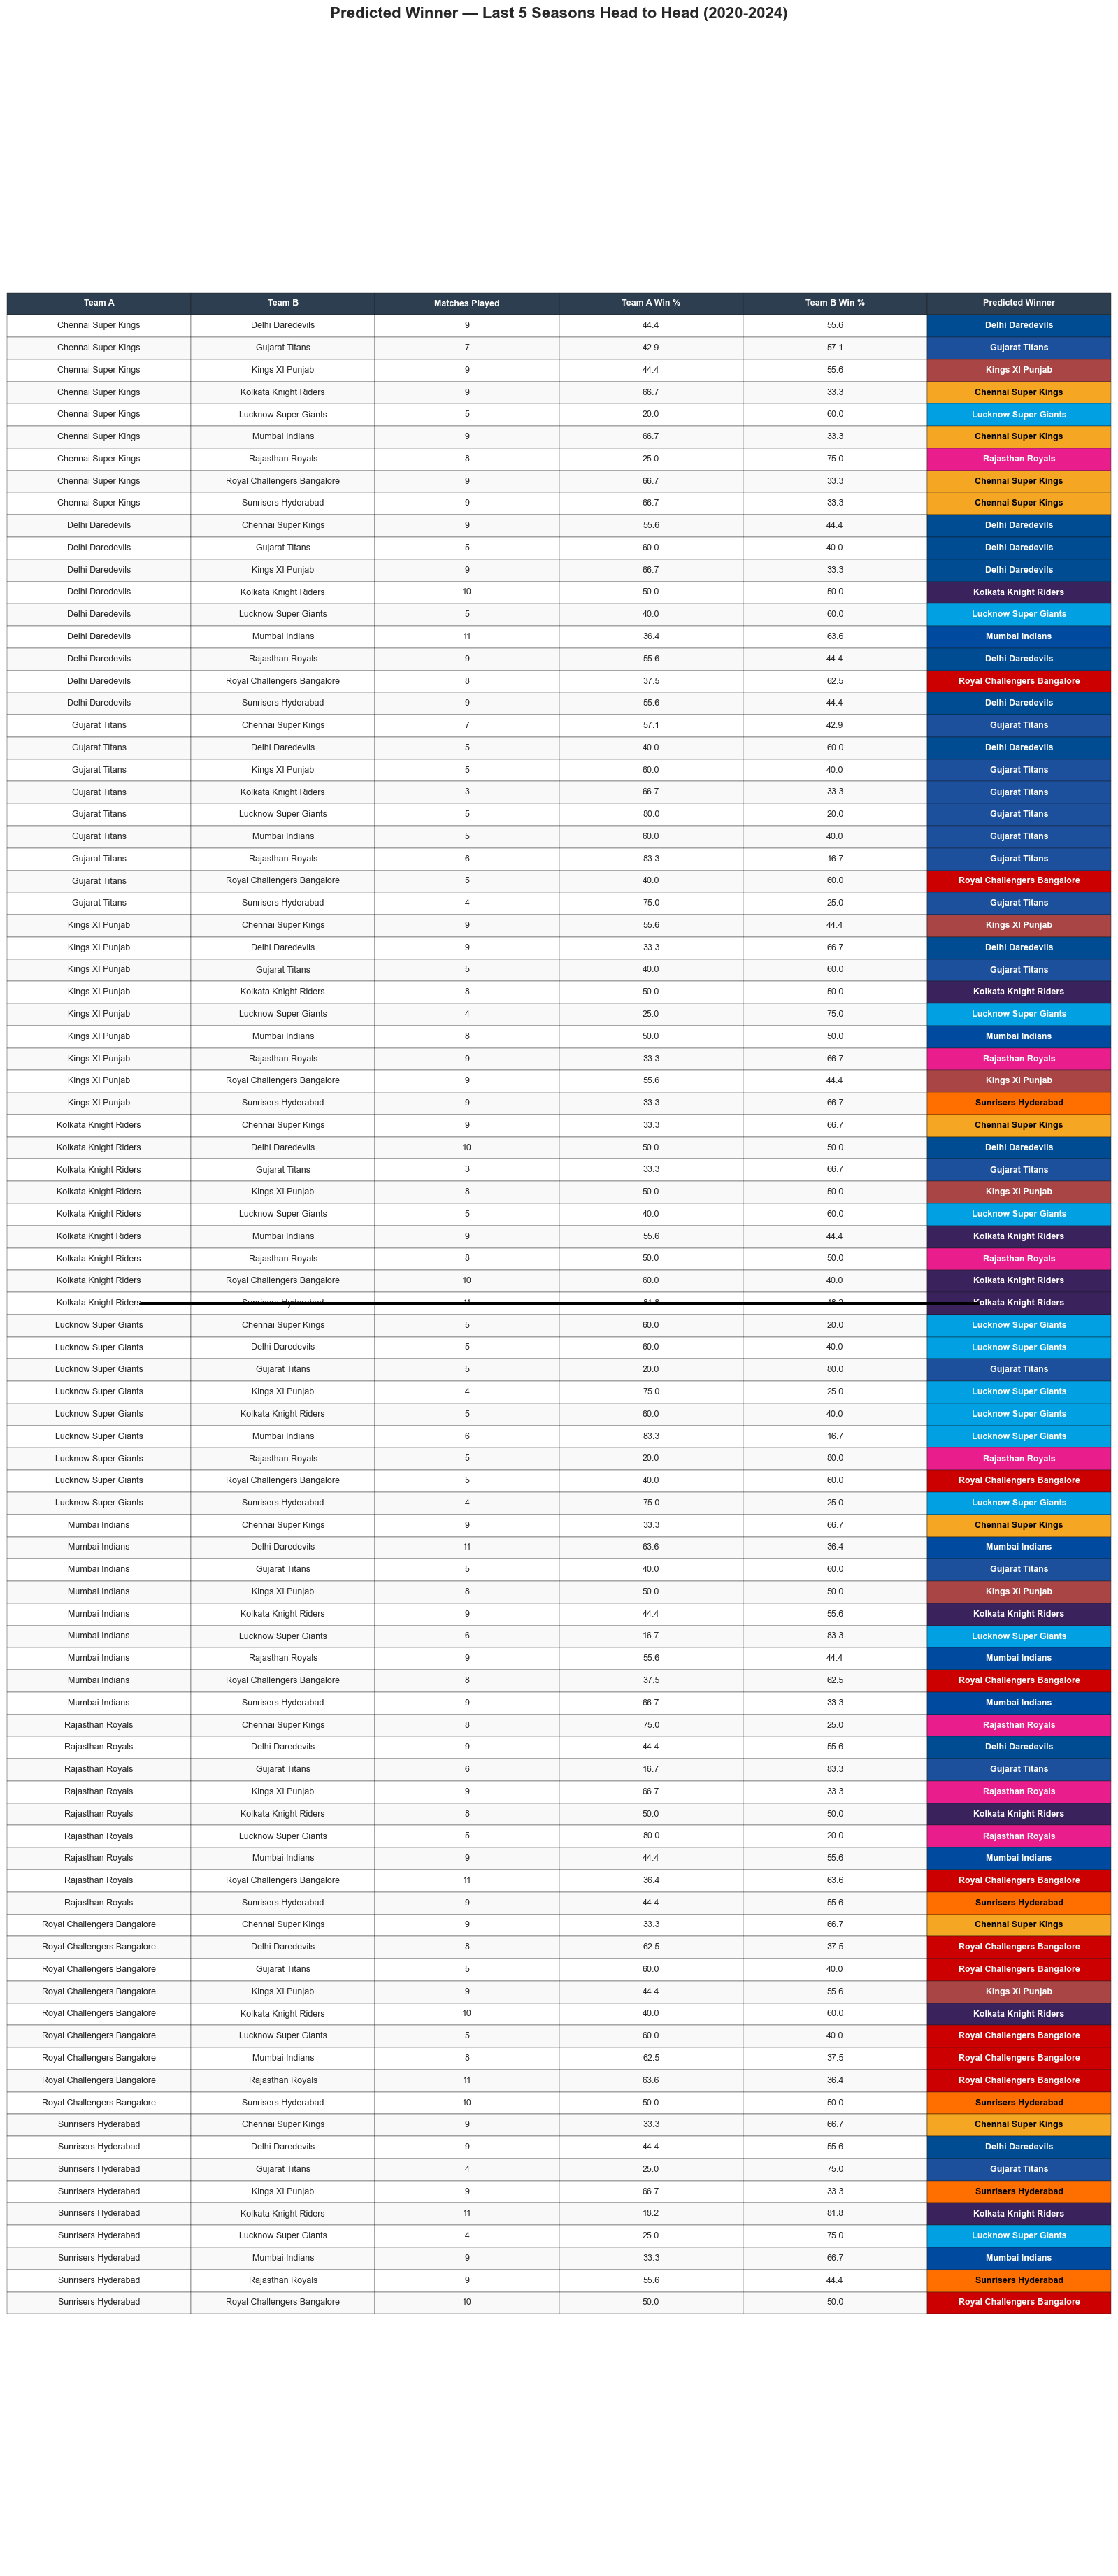

In [58]:
# --- LAST 5 SEASONS HEAD TO HEAD ---
recent_seasons = ['2020/21', '2021', '2022', '2023', '2024']
recent_matches = matches[matches['season'].isin(recent_seasons)]

active_teams = [
    'Chennai Super Kings',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Sunrisers Hyderabad',
    'Rajasthan Royals',
    'Delhi Daredevils',
    'Kings XI Punjab',
    'Lucknow Super Giants',
    'Gujarat Titans'
]

h2h_results_recent = []
for team_a in active_teams:
    for team_b in active_teams:
        if team_a == team_b:
            continue
        h2h = recent_matches[
            ((recent_matches['team1'] == team_a) & (recent_matches['team2'] == team_b)) |
            ((recent_matches['team1'] == team_b) & (recent_matches['team2'] == team_a))
        ]
        total = len(h2h)
        if total < 3:  # Lower threshold since fewer seasons
            continue
        team_a_wins = len(h2h[h2h['winner'] == team_a])
        team_b_wins = len(h2h[h2h['winner'] == team_b])
        team_a_prob = round(team_a_wins / total * 100, 1)
        team_b_prob = round(team_b_wins / total * 100, 1)
        predicted_winner = team_a if team_a_prob > team_b_prob else team_b

        h2h_results_recent.append({
            'Team A': team_a,
            'Team B': team_b,
            'Matches Played': total,
            'Team A Win %': team_a_prob,
            'Team B Win %': team_b_prob,
            'Predicted Winner': predicted_winner
        })

h2h_df_recent = pd.DataFrame(h2h_results_recent)

winner_df_recent = h2h_df_recent.sort_values(['Team A', 'Team B']).reset_index(drop=True)

# Find separator rows
separator_rows_recent = set()
prev_team = None
for idx, row in winner_df_recent.iterrows():
    if prev_team is not None and row['Team A'] != prev_team:
        separator_rows_recent.add(idx)
    prev_team = row['Team A']

fig, ax = plt.subplots(figsize=(16, len(winner_df_recent) * 0.4 + 1))
ax.axis('off')

table = ax.table(
    cellText=winner_df_recent.values,
    colLabels=winner_df_recent.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0.3)

    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 5 and row > 0:
        team = winner_df_recent.iloc[row - 1]['Predicted Winner']
        bg = team_colours.get(team, '#27ae60')
        fg = text_colours.get(team, '#ffffff')
        cell.set_facecolor(bg)
        cell.set_text_props(color=fg, fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f9f9f9')
    else:
        cell.set_facecolor('#ffffff')

    if row > 0 and (row - 1) in separator_rows_recent:
        cell.set_edgecolor('black')
        if col >= 0:
            x, y = cell.get_xy()
            width = cell.get_width()
            height = cell.get_height()
            ax.plot([x, x + width], [y + height, y + height],
                    color='black', linewidth=2.5,
                    transform=ax.transData, clip_on=False)

plt.title('Predicted Winner — Last 5 Seasons Head to Head (2020-2024)', fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
best_team = win_rates_df.iloc[0]['team']
best_win_rate = win_rates_df.iloc[0]['win_rate']
best_toss_converter = toss_effect.iloc[0]['team']
best_chasing_team = combined.sort_values('chase_win_rate', ascending=False).iloc[0]['team']
best_batting_first_team = combined.sort_values('bat_first_win_rate', ascending=False).iloc[0]['team']

print("=== TEAMS & SEASONS SUMMARY ===")
print(f"Best team all time (win rate): {best_team} ({best_win_rate}%)")
print(f"Best toss to match win converter: {best_toss_converter}")
print(f"Best chasing team: {best_chasing_team}")
print(f"Best batting first team: {best_batting_first_team}")

=== TEAMS & SEASONS SUMMARY ===
Best team all time (win rate): Gujarat Titans (62.2%)
Best toss to match win converter: Gujarat Lions
Best chasing team: Chennai Super Kings
Best batting first team: Chennai Super Kings
